# Quantum Trajectory

The origin of the Rabi oscillation in the second-order coherence is not clear from the solution of quantum master equation.  The quantum trajectory can visualize it very well.  Since the dissipation part is exactly the same as the case studied in {numref}`sec:qme`, we just need to ad the driving term in the system Hamiltonian. 

In [1]:
# ignore warnings (qutip issues various unwanted warnings)
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# reset random number
rng = np.random.default_rng()

def schroedinger(H,psi,dt):
    psi_new = (1 - 1j*H*dt) * psi
    return psi_new.unit()

def jump(c_ops,psi,dq):
    r = rng.random()
    if r < dq[0]:
        psi_new = c_ops[0] * psi
        flag=0
    else:
        psi_new = c_ops[1] * psi
        flag=1
    return psi_new.unit(),flag

# System parameters
omega0 = 1.0   # excitation energy
gamma0 = 0.1   # spontaneous emission rate
Delta = 0.0  # detuning
Omega = 1  # Rabi frequency
temperature = 1.0  # tempeature of photon gas
N = 1/(np.exp(omega0/temperature)-1) # Planck distribution

# Collapse operators
n_c_ops = 2
gamma1 = gamma0 * N   # coefficient to absorption
gamma2 = gamma0 * (N+1)  # coefficient to emission
c_ops = [np.sqrt(gamma1) * sigmap(),np.sqrt(gamma2) * sigmam()]
n = np.zeros([len(c_ops),1])
dq = np.zeros([len(c_ops),1])

# Effective Hamiltonian for a two-level system
H = 0.5*Delta*sigmaz() + 0.5*Omega*sigmax()
for i in range(len(c_ops)):
    H = H - 0.5j * c_ops[i].dag() * c_ops[i]

# set arrays for record
times = np.array([])   # time
spikes = np.array([])  # time when a photon is emitted
sz = np.array([]) # expectation value of sigma_z

# control parameters
# maximum number of photons to be counted
max_photons = 2000

# time step
dt = 0.1  

# number of photons emitted
n_photons = 0 

# current time
k=0 # loop counter
times = np.append(times,k*dt)

# random initial state vector
theta = rng.random()*2*np.pi
psi = basis(2,0)*np.sin(theta) + basis(2,1)*np.cos(theta)

# we measure sigmaz
sz = np.append(sz,expect(sigmaz(),psi))

# main loop begins
while n_photons < max_photons:

# set new time
    k += 1
    times = np.append(times,k*dt)

# calculate jump probability

    for j in range(len(c_ops)):
       n[j] = expect(c_ops[j].dag() * c_ops[j], psi)*dt
    dp = sum(n)
    dq = n/dp

# choose schraoedinger or jump step at random
    if rng.random() > dp:
        # Srhcoedinger step
        psi_new = schroedinger(H,psi,dt)

    else:
        # Jump step
        psi_new, flag = jump(c_ops,psi,dq)
        if flag == 1:  # emission
            spikes = np.append(spikes,times[k])
            n_photons += 1

# record the expectation value
    sz = np.append(sz,expect(sigmaz(),psi_new))

# set the state vector for next cycle
    psi=psi_new

## Quantum trajectory and jumps

The plot of the trajectory shows that the state smoothly oscillates between the ground ans excited states caused by the external driving .  Occasionally, it jumps up and down due to the interaction with the environment. The chance of jump down is higher when the system is in the excited state.  Suppose that photon was emitted and the system jumped sown to $|g\rangle$ at $t=0$.  The state is back to $|e\rangle$ at $t=(2n+1)\pi/\Omega$ where $n$ is integer.  Hence, the chance that two photons are emitted with time gap $(2n+1)\pi/\Omega$ is higher, resulting in photon bunching.  This correlation appears in the second-order coherence.

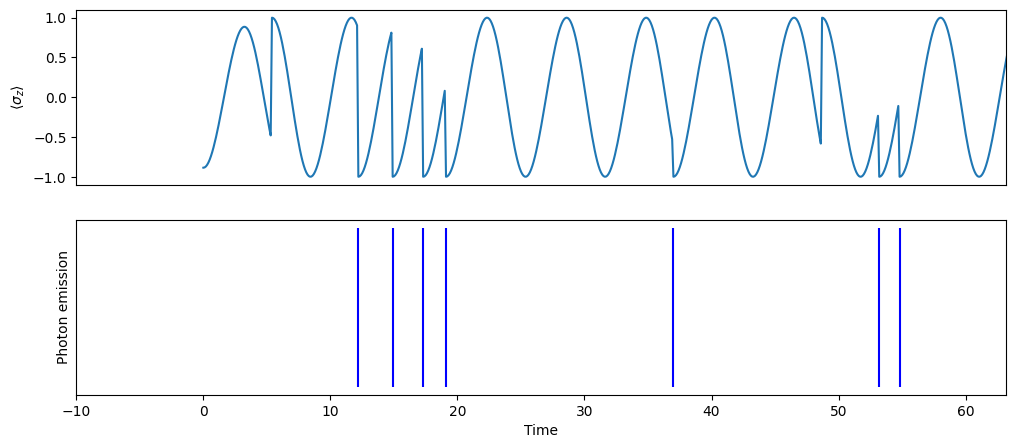

In [2]:
max_time = spikes[5]

plt.figure(figsize=(12, 5))
plt.subplot(2,1,1)
plt.plot(times,sz)
plt.xticks([])
plt.xlim([-10,max_time+10])
plt.ylabel(r"$\langle \sigma_z \rangle$")
plt.subplot(2,1,2)
plt.xlim([-10,max_time+10])
plt.yticks([])
plt.xlabel("Time")
plt.ylabel("Photon emission")
plt.vlines(spikes, 0, 1, color='b', label="emission")
plt.show()

## Waiting time distribution

After a photon is emitted, the next one tends to be emitted at $\tau_{n}=(2n+1)\pi/\Omega$, the waiting time distribution show peaks at $\tau_{n}$.  The peak height gradually descrease due to the memory loss with decay rate $\gamma$.  The following plot clear show that.

mean waiting time  =  12.4032016008004
standard deviation =  12.062663623002896
likely poissonian


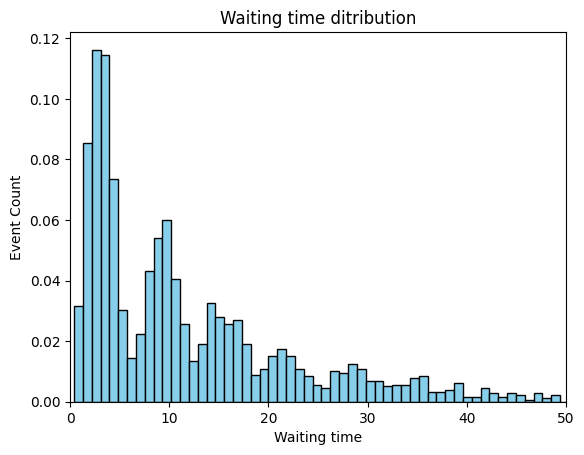

In [3]:
wtime = np.array([])
for i in range(max_photons-1):
    wtime = np.append(wtime,spikes[i+1]-spikes[i])

mean = sum(wtime)/len(wtime)
dev = np.sqrt(sum(wtime**2)/len(wtime) - mean**2)

print("mean waiting time  = ",mean)
print("standard deviation = ",dev)

if dev < 0.9*mean:
    print("likely sub-poissonian")
elif dev > 1.1*mean:
    print("likely super-poissonian")
else:
    print("likely poissonian")
    
plt.hist(wtime, density=True, bins=100, color='skyblue', edgecolor='black')
plt.title("Waiting time ditribution")
plt.xlim([0,50])
plt.xlabel("Waiting time")
plt.ylabel("Event Count")
plt.show()

## Second-order coherence

As we have seen above, the time separation between two photons is about $\tau_{n}$.  Hence, $g^{(2)}(\tau)$ should have peaks at $\tau_{n}$, corresponding to bunching.  The anti-bunching behavior at $\tau=0$ won't change even with the driving since two photons cannot be emitted at the same time.  Due to insufficient sampling, higher order peaks are hindered by statistical noises.  However, the first peak at $\tau_{1}$ is clearly visible.

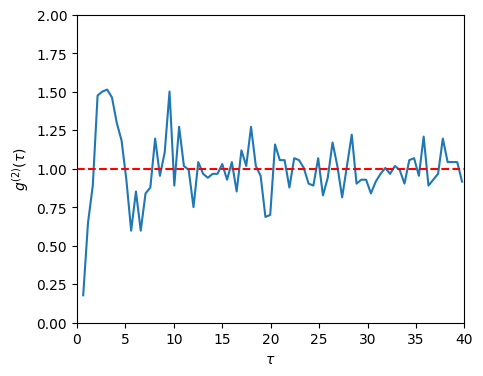

In [4]:
tau_max = 40  # max correlation time
N_spikes = len(spikes)
dN = 50

def pair_times(spikes):

    time_gap = np.array([])
    i=1


    while i < N_spikes-dN:
        t0 = spikes[i]
        j = i+1
        while  (j < N_spikes) :
            t1 = spikes[j]
            if t1-t0 <= tau_max:
                time_gap = np.append(time_gap,t1-t0)
                j += 1
            else:
                break
        i += 1
    return time_gap

pair_time_gap = pair_times(spikes)

nbins = 80
dtau = tau_max/nbins
norm = (N_spikes-dN)*N_spikes /spikes[N_spikes-1] * dtau 

counts, bin = np.histogram(pair_time_gap, bins=nbins)
n=len(bin)
x = (bin[0:n-1]+bin[1:n])/2
y = counts/norm

plt.figure(figsize=(5, 4))
plt.ylim([0,2])
plt.plot(x,y)
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.axhline(y=1, color='r', linestyle='--')
plt.show()